In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import PathPatch
import matplotlib as mpl

from matplotlib.colors import ListedColormap

import xarray as xr
import numpy as np
import matplotlib as mpl
from matplotlib import gridspec
import matplotlib.path as mpath
import matplotlib.colors as mcolors

from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.ticker as mticker
import cmocean.cm as cmocean
import dask.distributed as dask
import warnings
import intake
import cmcrameri

import sys
sys.path.append("/g/data/x77/ps7863/python_scripts/AABW_variability/")
import helper_funcs as helper

In [2]:
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [3]:
client = dask.Client(threads_per_worker = 1)
client


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41339 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41339/status,
Dashboard: /proxy/41339/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45749,Workers: 0
Dashboard: /proxy/41339/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37031,Total threads: 1
Dashboard: /proxy/34625/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:46337,


In [4]:
catalog = intake.cat.access_nri

In [5]:
figdir = '/g/data/x77/ps7863/figures/AABW_variability/bottom_500m/'
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'


In [6]:
# lon_slice = slice(80-360, 190-360)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [7]:
datastore = catalog[iaf_cycle3].search(variable='ht')
datastore = datastore.search(path=datastore.df.loc[0,'path'])
dataset = datastore.to_dask(xarray_open_kwargs = {"decode_timedelta" : True })
dataset = dataset.squeeze()

ht = dataset['ht']
land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)

In [8]:
shelf_mask = ht > 1000
shelf_mask = shelf_mask.astype(bool)
masked_shelf = shelf_mask.where(shelf_mask==0, np.nan)
shelf_mask = shelf_mask.where(shelf_mask==1, np.nan)
shelf_mask

<xarray.DataArray 'ht' (yt_ocean: 2700, xt_ocean: 3600)> Size: 78MB
dask.array<where, shape=(2700, 3600), dtype=float64, chunksize=(2700, 3600), chunktype=numpy.ndarray>
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      datetime64[ns] 8B 1900-01-01
Attributes:
    long_name:      ocean depth on t-cells
    units:          m
    valid_range:    [-1.e+09  1.e+09]
    cell_methods:   time: point
    standard_name:  sea_floor_depth_below_geoid

In [9]:
xt_ocean = ht.xt_ocean
yt_ocean = ht.yt_ocean

In [10]:
X, Y = np.meshgrid(xt_ocean, yt_ocean)
X = xr.DataArray(X, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])
Y = xr.DataArray(Y, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])

In [11]:
def make_boundary_path(longitudes, latitudes):
    """
    Return a path around boundary to create a sector map, then cut it out given
    longitudes and latitudes.
    """

    boundary_path = np.array([longitudes[-1, :], latitudes[-1, :]])
    boundary_path = np.append(
        boundary_path, np.array([longitudes[::-1, -1], latitudes[::-1, -1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[1, ::-1], latitudes[1, ::-1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[:, 1], latitudes[:, 1]]), axis=1
    )
    boundary_path = mpath.Path(np.swapaxes(boundary_path, 0, 1))

    return boundary_path

In [12]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [13]:
bathymetry = ht.load()
land =xr.where(np.isnan(bathymetry.rename("land")), 1, np.nan)
# land = land.assign_coords({"geolon_t": geolon_t, "geolat_t": geolat_t})

In [14]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [15]:
albw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/ALBW_range_detrended_1968-2018.nc')
rsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/RSBW_range_detrended_1968-2018.nc')
wsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/WSBW_range_detrended_1968-2018.nc')
pbbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/PBBW_range_detrended_1968-2018.nc')



In [16]:
albw_range = albw_range['ALBW_range']
pbbw_range = pbbw_range['PBBW_range']
rsbw_range = rsbw_range['RSBW_range']
wsbw_range = wsbw_range['WSBW_range']

In [17]:
albw_peak_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/ALBW_peak_month_1968-2018.nc')
rsbw_peak_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/RSBW_peak_month_1968-2018.nc')
wsbw_peak_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/WSBW_peak_month_1968-2018.nc')
pbbw_peak_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/PBBW_peak_month_1968-2018.nc') 


In [18]:
albw_peak_month = albw_peak_month['ALBW_peak_month']
rsbw_peak_month = rsbw_peak_month['RSBW_peak_month']
wsbw_peak_month = wsbw_peak_month['WSBW_peak_month']
pbbw_peak_month = pbbw_peak_month['PBBW_peak_month']

In [19]:
mask_rsbw = rsbw_range.where(rsbw_range >= 0.01, 0)
mask_rsbw = mask_rsbw.astype(bool)

mask_albw = albw_range.where(albw_range >= 0.01, 0)
mask_albw = mask_albw.astype(bool)

mask_wsbw = wsbw_range.where(wsbw_range >= 0.01, 0)
mask_wsbw = mask_wsbw.astype(bool)

mask_pbbw = pbbw_range.where(pbbw_range >= 0.01, 0)
mask_pbbw = mask_pbbw.astype(bool)

In [33]:
mask_rsbw.shape,rsbw_peak_month.shape, rsbw_range.shape

((666, 3600), (584, 1300), (666, 3600))

In [20]:
mask_rsbw = rsbw_range.where(rsbw_range >= 0.01, 1, 0)


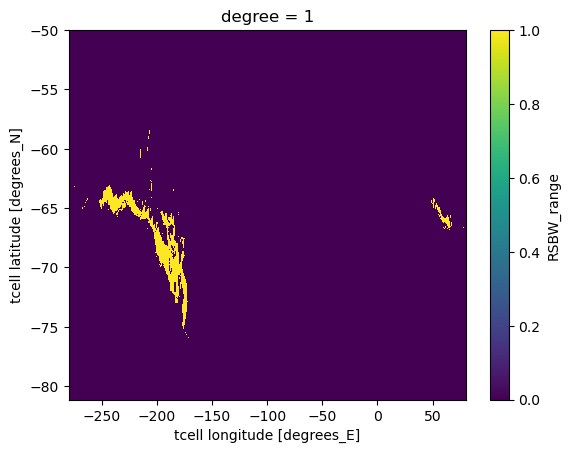

In [53]:
mask_rsbw = rsbw_range.where(rsbw_range >= 0.01, 0)
mask_rsbw = mask_rsbw.astype(bool)
mask_rsbw.plot()
# rsbw_peak_masked.where(rsbw_range >= 0.01, np.nan, 1).plot()

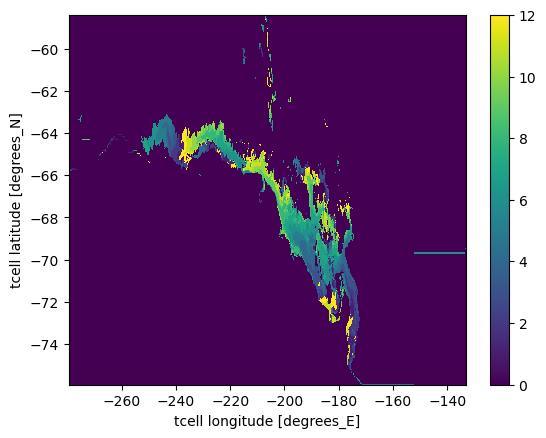

In [27]:
(rsbw_peak_month*mask_rsbw).plot()

In [20]:
# Define projection regions with correct orientation
regions = {
    "Ross": {
        "midlon": -215, "minlon": -250, "maxlon": -180,
        "minlat": -76, "maxlat": -60
    },
    "Weddell": {
        "midlon": -40, "minlon": -60, "maxlon": -20,
        "minlat": -76, "maxlat": -60
    },
    "Adelie": {
        "midlon": -230, "minlon": -250, "maxlon": -210,
        "minlat": -70, "maxlat": -60
    },
    "Prydz": {
        "midlon": 55, "minlon": 35, "maxlon": 75,
        "minlat": -70, "maxlat": -60
    }
}

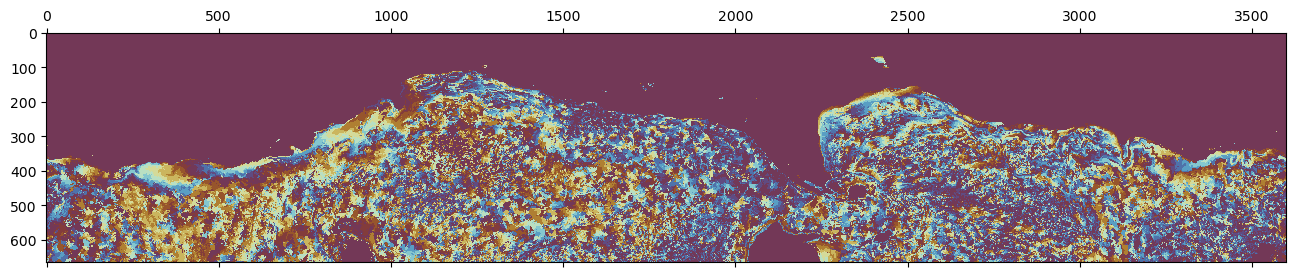

In [30]:
# create descrete cmap
cmap_continuous = cmcrameri.cm.romaO
N=12
colors = cmap_continuous(np.linspace(0, 1, N))

# Create a discrete colormap
romaO_discrete = ListedColormap(colors, name="romaO_discrete")
mat = plt.matshow(rsbw_peak_month, cmap=romaO_discrete, vmin=np.min(rsbw_peak_month) - 0.5, 
                      vmax=np.max(rsbw_peak_month) + 0.5)

## Load previously computed SWMT data

In [21]:
outpath = '/g/data/x77/ps7863/data/swmt/'

In [22]:
def get_SWMT(outpath):
    # net_transformation = xr.open_dataset(outpath + '/SWMT_' + time_bounds + '_adelie.nc', chunks={'isopycnal_bins':1})
    # net_transformation = net_transformation.surface_water_mass_transformation
    heat_transformation = xr.open_mfdataset(outpath + 'binned_heat_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    heat_transformation = heat_transformation.heat_transformation
    salt_transformation = xr.open_mfdataset(outpath + '/binned_salt_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    salt_transformation = salt_transformation.salt_transformation
    return heat_transformation, salt_transformation # net_transformation 

In [23]:
swmt_heat, swmt_salt = get_SWMT(outpath)
swmt_net = swmt_heat + swmt_salt

In [24]:
weddell_transformation_density = 37.355

weddell_subduction_plot = swmt_net.sel(isopycnal_bins = weddell_transformation_density, method='nearest') * 1e4
weddell_swmt_xt = weddell_subduction_plot.xt_ocean
weddell_swmt_yt = weddell_subduction_plot.yt_ocean

In [25]:
ross_transformation_density = 37.39
ross_subduction_plot = swmt_net.sel(isopycnal_bins=ross_transformation_density, method='nearest') * 1e4
# ross_subduction_plot = ross_subduction_plot * ross_mask
ross_subduction_plot = ross_subduction_plot.sortby(ross_subduction_plot.xt_ocean)

In [26]:
eastAA_transformation_density = 37.27
eastAA_subduction_plot = swmt_net.sel(isopycnal_bins=eastAA_transformation_density, method='nearest') * 1e4
eastAA_subduction_plot = eastAA_subduction_plot.sortby(eastAA_subduction_plot.xt_ocean)


In [27]:
prydz_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/prydz_tracer_mask.nc')
adelie_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/adelie_tracer_mask.nc') 
weddell_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/weddell_tracer_mask.nc')  
ross_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/ross_tracer_mask.nc')   
prydz_mask = prydz_mask['Prydz tracer mask']
adelie_mask = adelie_mask['Adelie tracer mask']
ross_mask = ross_mask['Ross tracer mask'] 
weddell_mask = weddell_mask['Weddell tracer mask']

In [28]:
# ross_mask = helper.convert_sort_coords(ross_mask)
# adelie_mask = helper.convert_sort_coords(adelie_mask)
weddell_mask = helper.convert_sort_coords(weddell_mask)

swmt_net = helper.convert_sort_coords(swmt_net) 
shelf = helper.convert_sort_coords(shelf)

# rsbw_peak_month = helper.wrap_centered(rsbw_peak_month,center=100)
# albw_peak_month = helper.wrap_centered(albw_peak_month,center=180)

In [56]:
adelie_mask

<xarray.DataArray 'Adelie tracer mask' (yt_ocean: 450, xt_ocean: 400)> Size: 1MB
[180000 values with dtype=float64]
Coordinates:
  * xt_ocean  (xt_ocean) float64 3kB -239.9 -239.8 -239.7 ... -200.1 -200.0
  * yt_ocean  (yt_ocean) float64 4kB -81.11 -81.07 -81.02 ... -62.03 -61.98
    st_ocean  float64 8B ...
    time      datetime64[ns] 8B ...

/jobfs/170289603.gadi-pbs/ipykernel_387909/332499044.py:113: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  (eastAA_subduction_plot*prydz_mask.drop('time')).mean('time').plot.pcolormesh(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/jobfs/170289603.gadi-pbs/ipykernel_387909/332499044.py:143: UserWarning: Adding colorbar to a different Figure <Figure size 1600x296 with 1 Axes> than <Figure size 700x600 with 6 Axes> which fig.colorbar is called on.
  cbar1 = plt.colorbar(mat, cax=cbar_ax1,


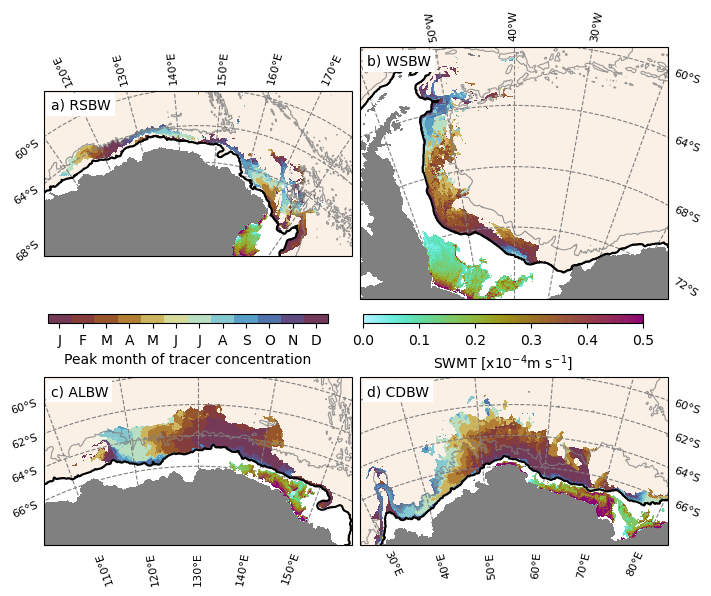

In [31]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
# fig.suptitle('Tracer concentration peak month')
norm = mcolors.TwoSlopeNorm(vmin=1, vcenter=6, vmax=12)
cmap = romaO_discrete
norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
cmap_smwt = cmcrameri.cm.hawaii_r

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
mask_color = 'linen'
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    # ax.add_feature(land_50m)
    # ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()


    if name=='Ross':
        pc=ax.pcolormesh(rsbw_peak_month.xt_ocean+360, rsbw_peak_month.yt_ocean, rsbw_peak_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(rsbw_peak_month.xt_ocean, rsbw_peak_month.yt_ocean, mask_rsbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'a) RSBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([110, 120, 130, 140, 150, 160, 170, 180])
        gl.ylocator = mticker.FixedLocator([-68, -64, -60])
        pc2=(ross_subduction_plot*ross_mask).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(), 
                cmap=cmap_smwt, 
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Weddell':
        pc=ax.pcolormesh(wsbw_peak_month.xt_ocean+360, wsbw_peak_month.yt_ocean, wsbw_peak_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()) 
        plt.contourf(wsbw_peak_month.xt_ocean, wsbw_peak_month.yt_ocean, mask_wsbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'b) WSBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.left_labels = False
        gl.ylocator = mticker.FixedLocator([-72, -68, -64, -60]) 
        (weddell_subduction_plot*weddell_mask).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(), 
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Adelie':
        pc=ax.pcolormesh(albw_peak_month.xt_ocean+360, albw_peak_month.yt_ocean, albw_peak_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(albw_peak_month.xt_ocean, albw_peak_month.yt_ocean, mask_albw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'c) ALBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.right_labels = False
        gl.top_labels = False
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.xlocator = mticker.FixedLocator([110, 120, 130, 140, 150])
        (eastAA_subduction_plot*adelie_mask).mean('time').plot.pcolormesh( 
                norm=norm_swmt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Prydz':        
        pc=ax.pcolormesh(pbbw_peak_month.xt_ocean+360, pbbw_peak_month.yt_ocean, pbbw_peak_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(pbbw_peak_month.xt_ocean, pbbw_peak_month.yt_ocean, mask_pbbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'd) CDBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.xlocator = mticker.FixedLocator([30, 40, 50, 60, 70, 80])
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.left_labels = False
        gl.top_labels = False
        (eastAA_subduction_plot*prydz_mask.drop('time')).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
    # LAND
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey'
            )
    ax.set_title('')
cbar_ax1 = fig.add_axes([0.06, 0.47, 0.4, 0.015])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.51, 0.47, 0.4, 0.015])

cbar1 = plt.colorbar(mat, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[1,2,3,4,5,6,7,8,9,10,11,12],
                     location='bottom'
                    )

cbar2 = plt.colorbar(pc2, cax=cbar_ax2,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                     location='bottom'
                    )
cbar1.ax.set_xticklabels(['J','F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
cbar1.set_label('Peak month of tracer concentration', fontsize=10)
cbar2.set_label(r'SWMT [x10$^{-4}$m s$^{-1}$]', fontsize=10)


# plt.tight_layout()
plt.savefig(f'{figdir}/tracer_peak_month_detrended_1968-2018.png', dpi=300, bbox_inches='tight')


In [63]:
albw_dip_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/ALBW_dip_month_1968-2018.nc')
rsbw_dip_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/RSBW_dip_month_1968-2018.nc')
pbbw_dip_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/PBBW_dip_month_1968-2018.nc')
wsbw_dip_month = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/WSBW_dip_month_1968-2018.nc')

albw_dip_month = albw_dip_month['ALBW_dip_month']
rsbw_dip_month = rsbw_dip_month['RSBW_dip_month']
pbbw_dip_month = pbbw_dip_month['PBBW_dip_month']
wsbw_dip_month = wsbw_dip_month['WSBW_dip_month']

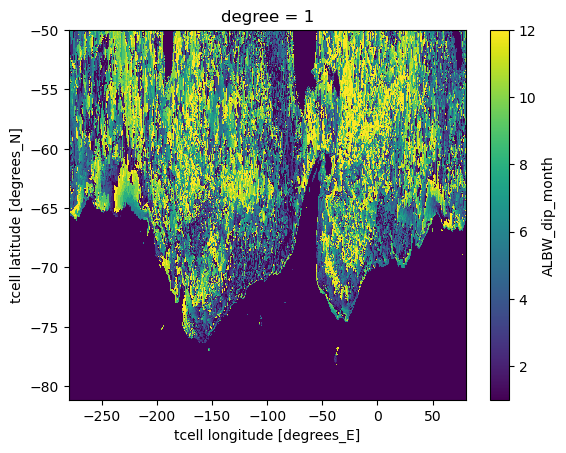

In [64]:
albw_dip_month.plot()

/jobfs/157036813.gadi-pbs/ipykernel_3989251/1031718026.py:113: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  (eastAA_subduction_plot*prydz_mask.drop('time')).mean('time').plot.pcolormesh(
/jobfs/157036813.gadi-pbs/ipykernel_3989251/1031718026.py:143: UserWarning: Adding colorbar to a different Figure <Figure size 1600x296 with 1 Axes> than <Figure size 700x600 with 6 Axes> which fig.colorbar is called on.
  cbar1 = plt.colorbar(mat, cax=cbar_ax1,


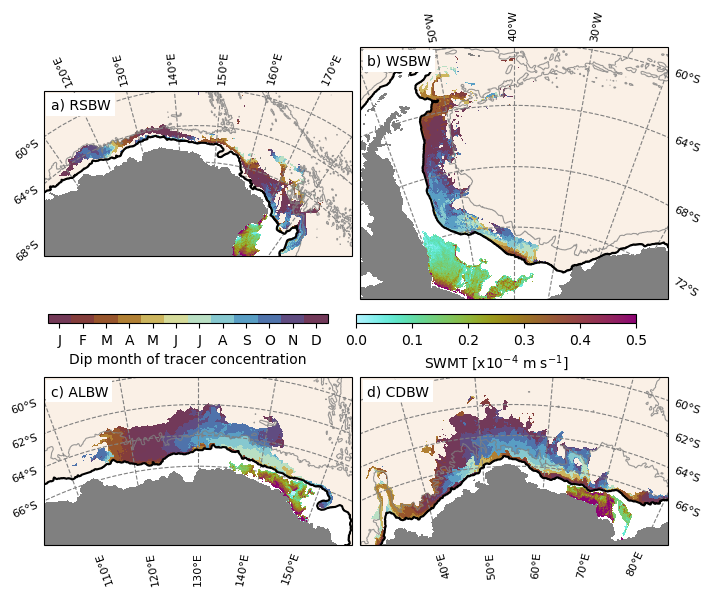

In [65]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
# fig.suptitle('Tracer concentration peak month')
norm = mcolors.TwoSlopeNorm(vmin=1, vcenter=6, vmax=12)
cmap = romaO_discrete
norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
cmap_smwt = cmcrameri.cm.hawaii_r

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
mask_color = 'linen'
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    # ax.add_feature(land_50m)
    # ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()


    if name=='Ross':
        pc=ax.pcolormesh(rsbw_dip_month.xt_ocean+360, rsbw_dip_month.yt_ocean, rsbw_dip_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(rsbw_dip_month.xt_ocean, rsbw_dip_month.yt_ocean, mask_rsbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'a) RSBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([110, 120, 130, 140, 150, 160, 170, 180])
        gl.ylocator = mticker.FixedLocator([-68, -64, -60])
        pc2=(ross_subduction_plot*ross_mask).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(), 
                cmap=cmap_smwt, 
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Weddell':
        pc=ax.pcolormesh(wsbw_dip_month.xt_ocean+360, wsbw_dip_month.yt_ocean, wsbw_dip_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()) 
        plt.contourf(wsbw_dip_month.xt_ocean, wsbw_dip_month.yt_ocean, mask_wsbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'b) WSBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.left_labels = False
        gl.ylocator = mticker.FixedLocator([-72, -68, -64, -60]) 
        (weddell_subduction_plot*weddell_mask).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(), 
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Adelie':
        pc=ax.pcolormesh(albw_dip_month.xt_ocean+360, albw_dip_month.yt_ocean, albw_dip_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(albw_dip_month.xt_ocean, albw_dip_month.yt_ocean, mask_albw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'c) ALBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.right_labels = False
        gl.top_labels = False
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.xlocator = mticker.FixedLocator([110, 120, 130, 140, 150])
        (eastAA_subduction_plot*adelie_mask).mean('time').plot.pcolormesh( 
                norm=norm_swmt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    if name=='Prydz':        
        pc=ax.pcolormesh(pbbw_dip_month.xt_ocean+360, pbbw_dip_month.yt_ocean, pbbw_dip_month, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(pbbw_dip_month.xt_ocean, pbbw_dip_month.yt_ocean, mask_pbbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'd) CDBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.xlocator = mticker.FixedLocator([40, 50, 60, 70, 80])
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.left_labels = False
        gl.top_labels = False
        (eastAA_subduction_plot*prydz_mask.drop('time')).mean('time').plot.pcolormesh(
                norm=norm_swmt,
                transform=ccrs.PlateCarree(),
                cmap=cmap_smwt,
                add_colorbar=False,
                zorder=4
                )
        
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
    # LAND
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey'
            )
    ax.set_title('')
cbar_ax1 = fig.add_axes([0.06, 0.47, 0.4, 0.015])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.5, 0.47, 0.4, 0.015])

cbar1 = plt.colorbar(mat, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[1,2,3,4,5,6,7,8,9,10,11,12],
                     location='bottom'
                    )

cbar2 = plt.colorbar(pc2, cax=cbar_ax2,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                     location='bottom'
                    )
cbar1.ax.set_xticklabels(['J','F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
cbar1.set_label('Dip month of tracer concentration', fontsize=10)
cbar2.set_label(r'SWMT [x10$^{-4}$ m s$^{-1}$]', fontsize=10)


# plt.tight_layout()
plt.savefig(f'{figdir}/AABW_tracer_dip_month_detrended_1968-2018.png', dpi=300, bbox_inches='tight')


In [9]:
from geopy.distance import geodesic 

In [28]:
prydz_overflow = [ -67, 68]
adelie_overflow = [-65.75, 143]
 
prydz_downstream = [ -68, 30]
adelie_downstream = [ -65, 110]

distance_prydz = geodesic(prydz_overflow,prydz_downstream).km
distance_adelie = geodesic(adelie_overflow,adelie_downstream).km

In [29]:
print('distance from Prydz overflow:', distance_prydz, 'distance from Adelie overflow:',distance_adelie)

distance from Prydz overflow: 1601.521781761131 distance from Adelie overflow: 1519.498425646661


## 1000 m 

In [15]:
albw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_1000m/ALBW_range_detrended_1968-2018.nc')
rsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_1000m/RSBW_range_detrended_1968-2018.nc')
# wsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/WSBW_range_detrended_1968-2018.nc')
# pbbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/PBBW_range_detrended_1968-2018.nc')



In [16]:
albw_range = albw_range['ALBW_range']
# pbbw_range = pbbw_range['PBBW_range']
rsbw_range = rsbw_range['RSBW_range']
# wsbw_range = wsbw_range['WSBW_range']

In [22]:
mask_rsbw = rsbw_range.where(rsbw_range >= 0.005, 0)
mask_rsbw = mask_rsbw.astype(bool)

mask_albw = albw_range.where(albw_range >= 0.01, 0)
mask_albw = mask_albw.astype(bool)

# mask_wsbw = wsbw_range.where(wsbw_range >= 0.01, 0)
# mask_wsbw = mask_wsbw.astype(bool)

# mask_pbbw = pbbw_range.where(pbbw_range >= 0.01, 0)
# mask_pbbw = mask_pbbw.astype(bool)

In [21]:
rsbw_peak_month_1000 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_1000m/RSBW_peak_month_1968-2018.nc')
albw_peak_month_1000 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_1000m/ALBW_peak_month_1968-2018.nc')
rsbw_peak_month_1000 = rsbw_peak_month_1000['RSBW_peak_month']
albw_peak_month_1000 = albw_peak_month_1000['ALBW_peak_month']

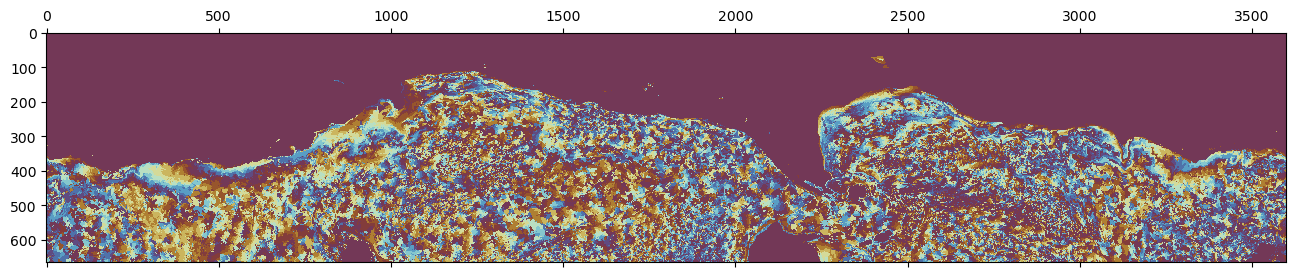

In [24]:
# create descrete cmap
cmap_continuous = cmcrameri.cm.romaO
N=12
colors = cmap_continuous(np.linspace(0, 1, N))

# Create a discrete colormap
romaO_discrete = ListedColormap(colors, name="romaO_discrete")
mat = plt.matshow(rsbw_peak_month_1000, cmap=romaO_discrete, vmin=np.min(rsbw_peak_month_1000) - 0.5, 
                      vmax=np.max(rsbw_peak_month_1000) + 0.5)

/jobfs/154570768.gadi-pbs/ipykernel_133609/1238170304.py:90: UserWarning: Adding colorbar to a different Figure <Figure size 1600x296 with 1 Axes> than <Figure size 700x600 with 6 Axes> which fig.colorbar is called on.
  cbar1 = plt.colorbar(mat, cax=cbar_ax1,


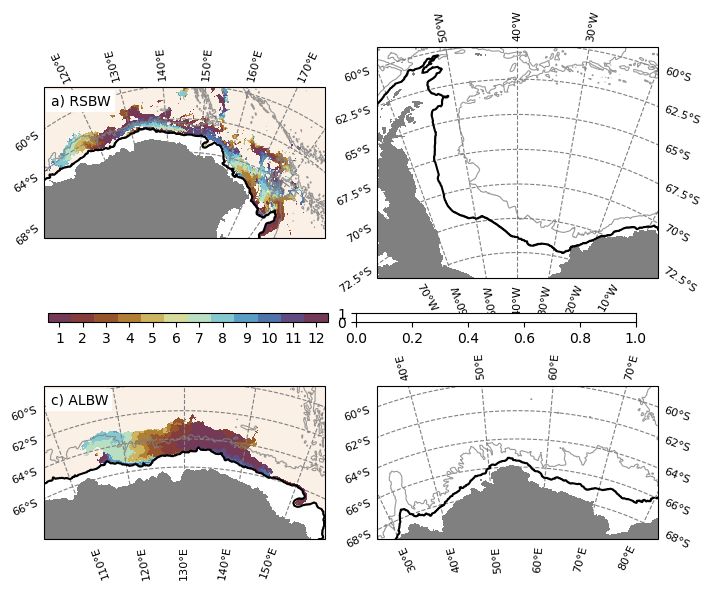

In [25]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
# fig.suptitle('Tracer concentration peak month')
norm = mcolors.TwoSlopeNorm(vmin=1, vcenter=6, vmax=12)
cmap = romaO_discrete
norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
cmap_smwt = cmcrameri.cm.hawaii_r

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
mask_color = 'linen'
# Plot each region

for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    # ax.add_feature(land_50m)
    # ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()


    if name=='Ross':
        pc=ax.pcolormesh(rsbw_peak_month_1000.xt_ocean+360, rsbw_peak_month_1000.yt_ocean, rsbw_peak_month_1000, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(rsbw_peak_month_1000.xt_ocean, rsbw_peak_month_1000.yt_ocean, mask_rsbw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'a) RSBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([120, 130, 140, 150, 160, 170, 180])
        gl.ylocator = mticker.FixedLocator([-68, -64, -60])

    if name=='Adelie':
        pc=ax.pcolormesh(albw_peak_month_1000.xt_ocean+360, albw_peak_month_1000.yt_ocean, albw_peak_month_1000, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        plt.contourf(albw_peak_month_1000.xt_ocean, albw_peak_month_1000.yt_ocean, mask_albw, levels=[0,0.5], colors=mask_color, transform=ccrs.PlateCarree())
        ax.annotate(
        'c) ALBW',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.right_labels = False
        gl.top_labels = False
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.xlocator = mticker.FixedLocator([110, 120, 130, 140, 150])

    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
    # LAND
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey'
            )
    ax.set_title('')

cbar_ax1 = fig.add_axes([0.06, 0.47, 0.4, 0.015])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.5, 0.47, 0.4, 0.015])

cbar1 = plt.colorbar(mat, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[1,2,3,4,5,6,7,8,9,10,11,12],
                     location='bottom'
                    )